# A Hedonic Analysis of Housing Prices in Moscow

## Research question
How do apartment characteristics such as size, metro accessibility, region, apartment type, and renovation affect housing prices in Moscow?

## Hypothesis
Larger apartments, better renovation, and shorter distance to metro are associated with higher prices.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# load data
df = pd.read_csv("data_moscow.csv")

# quick check
print(df.shape)
df.head()

(22676, 12)


,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['price', 'apartment_type', 'metro_station', 'minutes_to_metro',
       'region', 'number_of_rooms', 'area', 'living_area', 'kitchen_area',
       'floor', 'number_of_floors', 'renovation'],
      dtype='object')

In [12]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             22676 non-null  float64
 1   apartment_type    22676 non-null  object 
 2   metro_station     22676 non-null  object 
 3   minutes_to_metro  22676 non-null  float64
 4   region            22676 non-null  object 
 5   number_of_rooms   22676 non-null  float64
 6   area              22676 non-null  float64
 7   living_area       22676 non-null  float64
 8   kitchen_area      22676 non-null  float64
 9   floor             22676 non-null  float64
 10  number_of_floors  22676 non-null  int64  
 11  renovation        22676 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 2.1+ MB


,price,apartment_type,metro_station,minutes_to_metro,region,number_of_rooms,area,living_area,kitchen_area,floor,number_of_floors,renovation
count,2.267600e+04,22676,22676,22676.000000,22676,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676
unique,NaN,2,547,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Secondary,Красногвардейская,NaN,Moscow,NaN,NaN,NaN,NaN,NaN,NaN,Cosmetic
freq,NaN,13152,2697,NaN,16113,NaN,NaN,NaN,NaN,NaN,NaN,12788
mean,3.612132e+07,NaN,NaN,11.888605,NaN,2.043129,71.966827,38.517953,12.594082,9.190466,16.556095,NaN
std,8.282561e+07,NaN,NaN,6.204457,NaN,1.523586,68.368608,38.124278,7.728074,7.549996,9.779297,NaN
min,1.150000e+06,NaN,NaN,0.000000,NaN,0.000000,6.000000,2.000000,1.000000,1.000000,1.000000,NaN
25%,7.068116e+06,NaN,NaN,7.000000,NaN,1.000000,37.400000,17.600000,8.600000,4.000000,11.000000,NaN
50%,1.134320e+07,NaN,NaN,11.000000,NaN,2.000000,53.300000,28.500000,10.600000,8.000000,16.000000,NaN
75%,2.479925e+07,NaN,NaN,15.000000,NaN,3.000000,77.140000,43.200000,14.500000,13.000000,20.000000,NaN


The dataset contains apartment-level observations for Moscow and the Moscow region. Key variables include price, size, accessibility to metro, building characteristics, and renovation status.

In [13]:
df = df.copy()

df["log_price"] = np.log(df["price"])
df["log_area"] = np.log(df["area"])
df["price_per_sqm"] = df["price"] / df["area"]
df["floor_ratio"] = df["floor"] / df["number_of_floors"]

df[["price", "area", "log_price", "log_area", "price_per_sqm", "floor_ratio"]].head()

,price,area,log_price,log_area,price_per_sqm,floor_ratio
0,6300000.0,30.6,15.656060,3.421000,205882.352941,1.000000
1,9000000.0,49.2,16.012735,3.895894,182926.829268,0.400000
2,11090000.0,44.7,16.221554,3.799974,248098.434004,0.400000
3,8300000.0,35.1,15.931766,3.558201,236467.236467,0.363636
4,6450000.0,37.7,15.679591,3.629660,171087.533156,1.000000


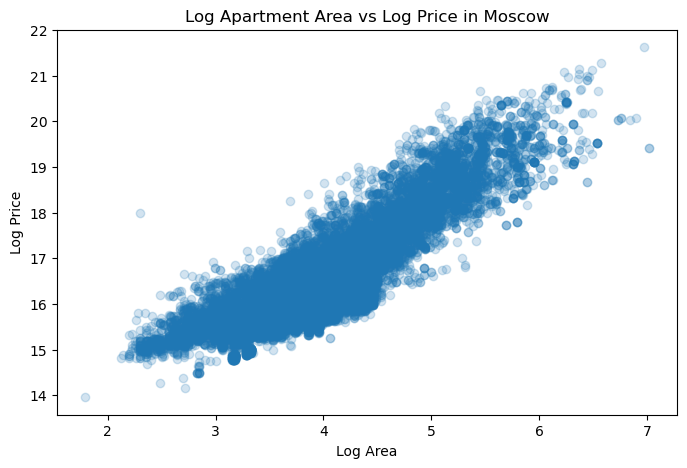

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["log_area"], df["log_price"], alpha=0.2)
plt.title("Log Apartment Area vs Log Price in Moscow")
plt.xlabel("Log Area")
plt.ylabel("Log Price")
plt.show()

<Figure size 900x500 with 0 Axes>

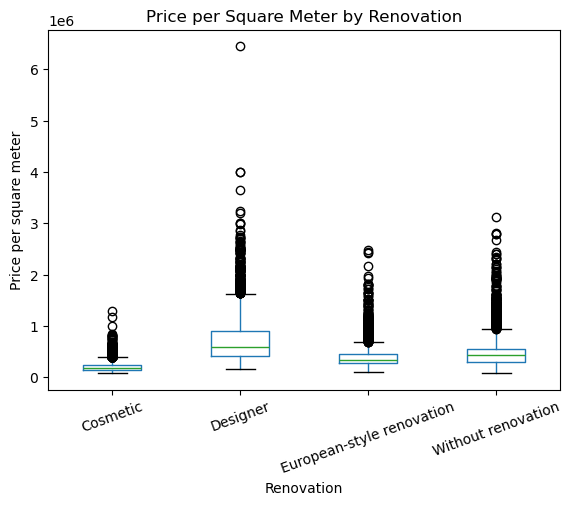

In [15]:
renovation_order = ["Without renovation", "Cosmetic", "European-style renovation", "Designer"]

plt.figure(figsize=(9, 5))
df.boxplot(column="price_per_sqm", by="renovation", grid=False)
plt.title("Price per Square Meter by Renovation")
plt.suptitle("")
plt.xlabel("Renovation")
plt.ylabel("Price per square meter")
plt.xticks(rotation=20)
plt.show()

In [16]:
model = smf.ols(
    formula="""
    log_price ~ log_area
              + minutes_to_metro
              + C(region)
              + C(apartment_type)
              + C(renovation)
              + floor_ratio
    """,
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                 2.889e+04
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:38:53   Log-Likelihood:                -6963.4
No. Observations:               22676   AIC:                         1.394e+04
Df Residuals:                   22667   BIC:                         1.402e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

## Initial interpretation of the regression

The regression suggests that apartment size is a major predictor of housing price, as the coefficient on log area is expected to be positive and statistically significant.

Minutes to metro is expected to have a negative relationship with price, meaning apartments farther from metro stations tend to be cheaper.

Renovation status and apartment type likely capture important quality differences across listings.

Overall, the model appears useful for explaining price variation, but it has important limitations: the data are cross-sectional, exact neighborhood quality is not fully observed, and listing prices may differ from final transaction prices.

In [28]:
from src.housing_utils import (
    load_data,
    prepare_features,
    plot_area_vs_price,
    plot_price_by_renovation,
    fit_baseline_model,
)

df = load_data("data/data_moscow.csv")
df = prepare_features(df)

df.head()

,price,apartment_type,metro_station,minutes_to_metro,region,number_of_rooms,area,living_area,kitchen_area,floor,number_of_floors,renovation,log_price,log_area,price_per_sqm,floor_ratio
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic,15.656060,3.421000,205882.352941,1.000000
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation,16.012735,3.895894,182926.829268,0.400000
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic,16.221554,3.799974,248098.434004,0.400000
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation,15.931766,3.558201,236467.236467,0.363636
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation,15.679591,3.629660,171087.533156,1.000000


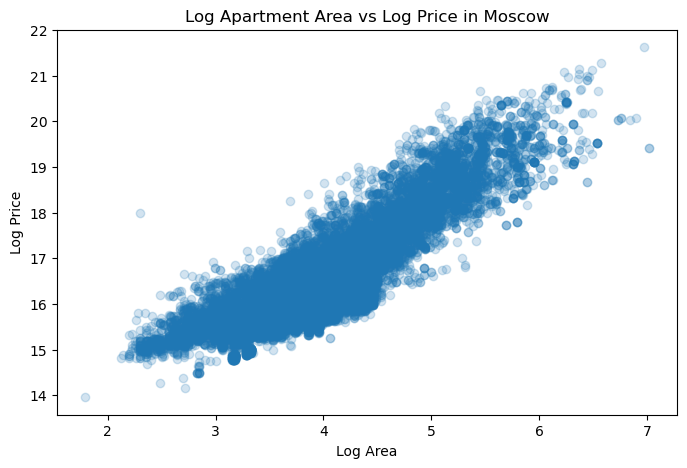

<Figure size 900x500 with 0 Axes>

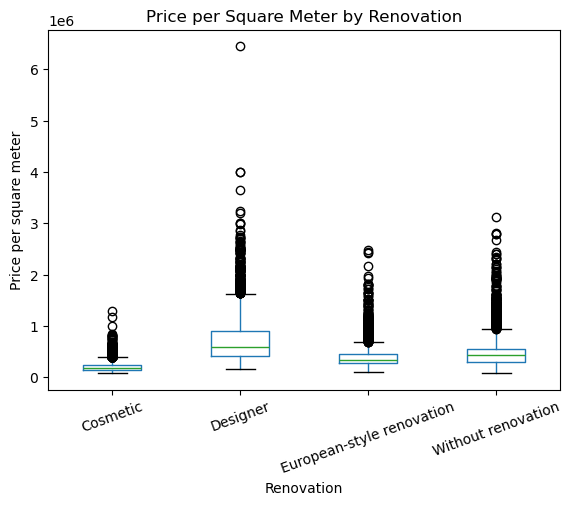

In [29]:
plot_area_vs_price(df)
plot_price_by_renovation(df)

In [30]:
model = fit_baseline_model(df)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                 2.889e+04
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:12:33   Log-Likelihood:                -6963.4
No. Observations:               22676   AIC:                         1.394e+04
Df Residuals:                   22667   BIC:                         1.402e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [31]:
import sys
import os
sys.path.append(os.getcwd())

In [26]:
!python -m pytest -q

..                                                                       [100%]
2 passed in 1.90s


In [27]:
python -m pytest -q

SyntaxError: invalid syntax (2021844404.py, line 1)